# Criar uma máscara por slice 
 - Procurar todos os arquivos rocha*.tiff na pasta.

- Para cada slice, procurar os arquivos correspondentes de poro e fundo.

- Gerar a máscara multiclasse combinada para aquele slice.

- Salvar a máscara com nome padrão, por exemplo: maskXXXX.tiff.

- Exibir mensagem se algum arquivo estiver faltando.

In [1]:
import os
import numpy as np
import imageio.v3 as iio
import re

pasta = r"E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin"

# Função para extrair o número do slice do nome do arquivo (ex: "rocha0001.tiff" -> "0001")
def extrair_numero(nome_arquivo):
    m = re.search(r'\d+', nome_arquivo)
    return m.group(0) if m else None

# Listar todos arquivos da pasta que começam com 'rocha' e terminam com '.tiff'
arquivos_rocha = [f for f in os.listdir(pasta) if f.startswith('rocha') and f.endswith('.tiff')]

print(f"{len(arquivos_rocha)} arquivos de rocha encontrados.")

for arquivo_rocha in sorted(arquivos_rocha):
    numero = extrair_numero(arquivo_rocha)
    if numero is None:
        print(f"Não consegui extrair número do arquivo {arquivo_rocha}, pulando...")
        continue

    arquivo_poros = f"poro{numero}.tiff"
    arquivo_fundo = f"fundo{numero}.tiff"
    saida = f"mask{numero}.tiff"

    caminho_rocha = os.path.join(pasta, arquivo_rocha)
    caminho_poros = os.path.join(pasta, arquivo_poros)
    caminho_fundo = os.path.join(pasta, arquivo_fundo)
    caminho_saida = os.path.join(pasta, saida)

    # Verificar se os arquivos existem
    if not (os.path.isfile(caminho_poros) and os.path.isfile(caminho_fundo)):
        print(f"Arquivos correspondentes ao slice {numero} faltando, pulando...")
        continue

    # Carregar imagens
    rocha = iio.imread(caminho_rocha)
    poros = iio.imread(caminho_poros)
    fundo = iio.imread(caminho_fundo)

    # Converter 255 -> 1
    rocha_bin = (rocha > 128).astype(np.uint8)
    poros_bin = (poros > 128).astype(np.uint8)
    fundo_bin = (fundo > 128).astype(np.uint8)

    # Criar máscara multiclasse
    mask = np.zeros_like(rocha_bin, dtype=np.uint8)
    mask[fundo_bin == 1] = 0
    mask[rocha_bin == 1] = 1
    mask[poros_bin == 1] = 2

    # Salvar máscara
    iio.imwrite(caminho_saida, mask)
    print(f"Máscara salva para slice {numero} em {caminho_saida}")

print("Processamento finalizado.")

1085 arquivos de rocha encontrados.
Máscara salva para slice 0001 em E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin\mask0001.tiff
Máscara salva para slice 0002 em E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin\mask0002.tiff
Máscara salva para slice 0003 em E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin\mask0003.tiff
Máscara salva para slice 0004 em E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin\mask0004.tiff
Máscara salva para slice 0005 em E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin\mask0005.tiff
Máscara salva para slice 0006 em E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin\mask0006.tiff
Máscara salva para slice 0007 em E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin\mask0007.tiff
Máscara salva para slice 0008 em E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin\mask0008.tiff
Máscara salva para slice 0009 em E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin\mask0009.tiff
Máscara salva para 

### Carregar e visualizar uma imagem ou máscara específica:
- Carrega a imagem e a máscara correspondentes e exibi-las.

- Visualiza um slice (como rocha, poros, fundo) e a máscara gerada

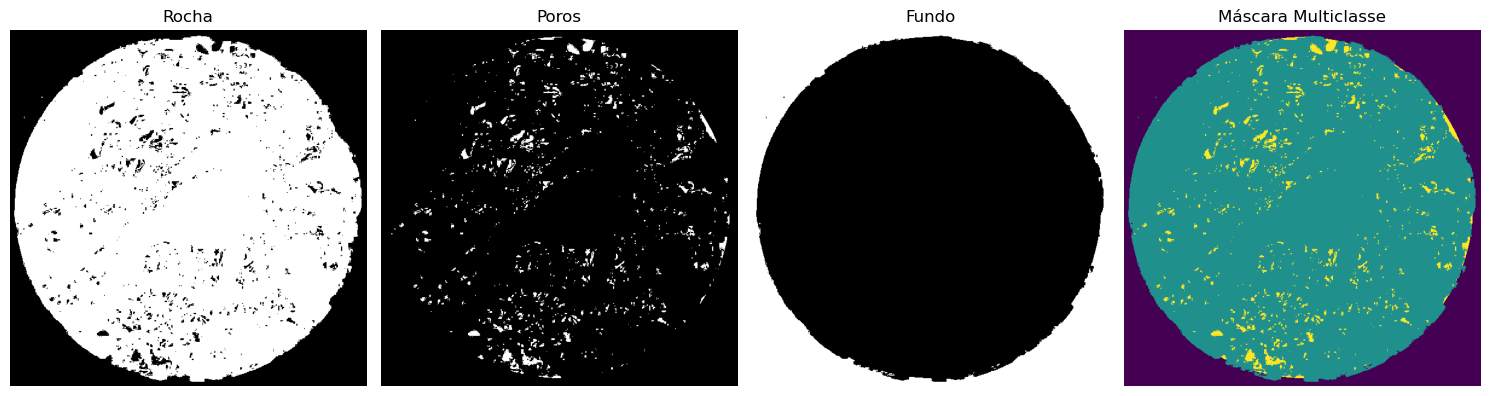

In [3]:
import matplotlib.pyplot as plt
import imageio.v3 as iio
import os

# Caminho do seu diretório
pasta = r"E:\back_up_DOUTORADO\4_CPE883_ML2_2p\00_imagens_teste\bin"

# Número do slice para visualizar
numero = "0002"  # Exemplo: slice0001

# Carregar as imagens (rocha, poros, fundo) e a máscara
arquivo_rocha = f"rocha{numero}.tiff"
arquivo_poros = f"poro{numero}.tiff"
arquivo_fundo = f"fundo{numero}.tiff"
arquivo_mask = f"mask{numero}.tiff"

# Caminhos completos
caminho_rocha = os.path.join(pasta, arquivo_rocha)
caminho_poros = os.path.join(pasta, arquivo_poros)
caminho_fundo = os.path.join(pasta, arquivo_fundo)
caminho_mask = os.path.join(pasta, arquivo_mask)

# Carregar as imagens
rocha = iio.imread(caminho_rocha)
poros = iio.imread(caminho_poros)
fundo = iio.imread(caminho_fundo)
mask = iio.imread(caminho_mask)

# Plotar as imagens lado a lado
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Mostrar a imagem de rocha
axes[0].imshow(rocha, cmap='gray')
axes[0].set_title('Rocha')
axes[0].axis('off')

# Mostrar a imagem de poros
axes[1].imshow(poros, cmap='gray')
axes[1].set_title('Poros')
axes[1].axis('off')

# Mostrar a imagem de fundo
axes[2].imshow(fundo, cmap='gray')
axes[2].set_title('Fundo')
axes[2].axis('off')

# Mostrar a máscara
axes[3].imshow(mask, cmap='viridis')
axes[3].set_title('Máscara Multiclasse')
axes[3].axis('off')

# Exibir as imagens
plt.tight_layout()
plt.show()